# Individual Household Electric Power Consumption using Neural Network
## Dataset: Individual Household Electric Power Consumption - UC Irvine Machine Learning Repository

The Individual Household Electric Power Consumption dataset contains measurements of electric power consumption in one household with a one-minute sampling rate over a period of nearly four years. This project aims to predict various attributes related to electric power consumption using a multilayer neural network.

## Dataset Features
- **Date**: Date of the measurement (in the format dd/mm/yyyy)
- **Time**: Time of the measurement (in the format hh:mm:ss)
- **Global_active_power**: The household's global active power (kilowatts)
- **Global_reactive_power**: The household's global reactive power (kilowatts)
- **Voltage**: The voltage (volts)
- **Global_intensity**: The household's global current intensity (amperes)
- **Sub_metering_1**: Energy sub-metering No. 1 (watt-hour of active energy, corresponds to the kitchen)
- **Sub_metering_2**: Energy sub-metering No. 2 (watt-hour of active energy, corresponds to the laundry room)
- **Sub_metering_3**: Energy sub-metering No. 3 (watt-hour of active energy, corresponds to an electric water heater and an air-conditioner)

In [ ]:
pip install --upgrade scikit-learn

In [ ]:
pip install ucimlrepo

### Step 1: Importing Libraries and Dataset
In this step, we import the necessary libraries for data manipulation, visualization, preprocessing, and model development. We utilize **NumPy** and **Pandas** for data handling, while **Matplotlib** aids in visualizing the dataset. The **TensorFlow** framework is used for building the neural network, and **scikit-learn** provides tools for model evaluation and data preprocessing tasks such as scaling features and calculating class weights. Additionally, the **ucimlrepo** library is used to fetch the dataset directly from the UCI Machine Learning Repository for convenience.

In [ ]:
# Import libraries for data manipulation and numerical operations
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import TensorFlow for building neural network models
import tensorflow as tf

# Import Keras callbacks for model training support
from keras.callbacks import EarlyStopping

# Import scikit-learn modules for model training, evaluation, and data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight, resample
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Import dataset utility from the UCI Machine Learning Repository
from ucimlrepo import fetch_ucirepo

### Step 2: Loading and Preparing the Dataset
In this step, we fetch the **Individual Household Electric Power Consumption** dataset using the `fetch_ucirepo` function, which retrieves the dataset by its ID from the UCI Machine Learning Repository. We extract the features (`X`) from the dataset and store them in a DataFrame for better readability, with the column names matching the dataset's variables. The target variable (`y`) is assigned to `Global_active_power`, which represents the household's global active power consumption. Finally, we display the first few rows of the DataFrame to inspect the data structure.

In [ ]:
# Fetch the Individual Household Electric Power Consumption dataset from the UCI Machine Learning Repository
household_electric_power_consumption = fetch_ucirepo(id=235)

# Extract features from the dataset
X = household_electric_power_consumption.data.features

# Create a DataFrame with the extracted features, using the dataset's variable names as columns
df = pd.DataFrame(X, columns=household_electric_power_consumption.name)

# Assign the target variable 'Global_active_power' from the DataFrame
y = df["Global_active_power"]

# Display the first few rows of the DataFrame to inspect the data structure
df.head()

/usr/local/lib/python3.10/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


### Step 3: Data Cleaning
In this step, we perform basic data cleaning on the **Individual Household Electric Power Consumption** dataset. We start by dropping the `Date` and `Time` columns, as they are not required for the prediction task. Next, we remove any rows containing missing values (`NaN`) to ensure a clean dataset for model training. The cleaned DataFrame is then ready for further analysis and modeling.

In [ ]:
# Drop the 'Date' and 'Time' columns from the DataFrame, as they are not needed for the prediction task
df = df.drop(["Date", "Time"], axis=1)

# Remove any rows containing missing values (NaN) to ensure a clean dataset for model training
df = df.dropna()

# Display the cleaned DataFrame to verify the changes
df

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,3.666,0.528,235.680,15.800,0.000,1.000,17.0
...,...,...,...,...,...,...,...
2075254,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2075256,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,0.934,0.0,239.7,3.8,0.0,0.0,0.0


### Step 4: Feature Scaling
In this step, we apply feature scaling to the cleaned dataset using the **MinMaxScaler**. This scaler transforms the features to a range between 0 and 1, which is essential for neural network training to ensure that all input features contribute equally to the model's learning process.

We start by fitting the scaler to the DataFrame (`df`) and transforming the data into a scaled format, which is stored in `standard_data`. We then create a new DataFrame (`standard_df`) with the scaled data and the original column names.

Next, we separate the target variable (`Global_active_power`) from the features. The target variable is stored in `standard_y`, and the corresponding column is dropped from the features DataFrame. Finally, we add the target variable back into the scaled features DataFrame as a new column named `Target`, and we convert `standard_y` into a NumPy array for compatibility with model training.

The first few rows of the scaled DataFrame are displayed to verify the transformations.

In [ ]:
# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler to the DataFrame and transform the data into a scaled format
standard_data = scaler.fit_transform(df)

# Create a new DataFrame with the scaled data and the original column names
standard_df = pd.DataFrame(standard_data, columns=df.columns)

# Separate the target variable 'Global_active_power' from the features
standard_y = standard_df["Global_active_power"]
standard_df = standard_df.drop(["Global_active_power"], axis=1)

# Add the target variable back into the scaled features DataFrame as a new column named 'Target'
standard_df["Target"] = standard_y.values

# Convert the target variable into a NumPy array for compatibility with model training
standard_y = np.array(standard_y)

# Display the first few rows of the scaled DataFrame to verify the transformations
standard_df.head()

,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Target
0,0.300719,0.376090,0.377593,0.0,0.0125,0.548387,0.374796
1,0.313669,0.336995,0.473029,0.0,0.0125,0.516129,0.478363
2,0.358273,0.326010,0.473029,0.0,0.0250,0.548387,0.479631
3,0.361151,0.340549,0.473029,0.0,0.0125,0.548387,0.480898
4,0.379856,0.403231,0.323651,0.0,0.0125,0.548387,0.325005


### Step 5: Data Visualization
In this step, we visualize the distribution of the **Global Active Power** using a histogram. This provides insights into the frequency of different power consumption levels within the dataset.

We create a figure for the histogram. The histogram is plotted using `standard_y`, which represents the scaled values of global active power, with 50 bins for granularity. The bars are colored sky blue with black edges for clarity.

We also set the title of the plot to "Distribution of Global Active Power" and label the x-axis as "Global Active Power (kilowatts)" and the y-axis as "Frequency." A grid is added to the y-axis for easier interpretation of the frequencies.

Finally, we display the plot using `plt.show()`, allowing us to observe the distribution of global active power consumption across the dataset.

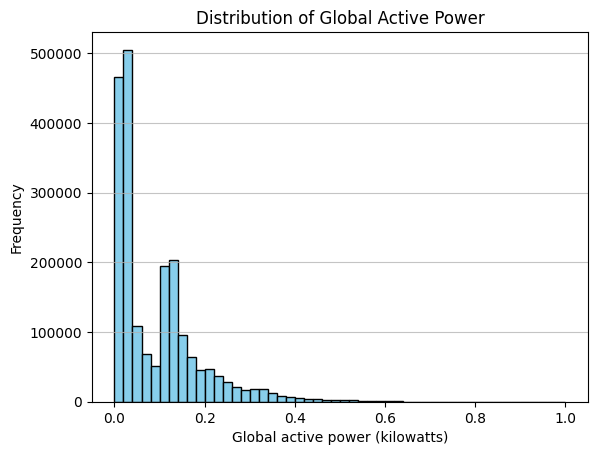

In [ ]:
# Create a new figure for the histogram
plt.figure()

# Plot a histogram of the Global Active Power with specified bins and colors
plt.hist(standard_y, bins=50, color="skyblue", edgecolor="black")

# Set the title and labels for the axes
plt.title("Distribution of Global Active Power")
plt.xlabel("Global Active Power (kilowatts)")
plt.ylabel("Frequency")

# Add gridlines to the y-axis for better readability
plt.grid(axis="y", alpha=0.75)

# Display the histogram
plt.show()

### Step 6: Splitting the Dataset
In this step, we prepare the data for training and testing the model by splitting the dataset into training and testing sets.

First, we define the feature set `X` by dropping the `Target` column from the scaled DataFrame (`standard_df`), as it contains the values we want to predict.

We then use the `train_test_split` function to divide the features and target variable into training and testing sets. The dataset is split such that 80% of the data is used for training (`X_train` and `y_train`) and 20% is reserved for testing (`X_test` and `y_test`). The `random_state` parameter is set to 42 to ensure reproducibility of the split across different runs.

This process helps in evaluating the model's performance on unseen data after training.

In [ ]:
# Define the feature set by dropping the Target column from the scaled DataFrame
X = standard_df.drop(["Target"], axis=1)

# Split the dataset into training and testing sets
# 80% of the data is used for training, and 20% is reserved for testing
X_train, X_test, y_train, y_test = train_test_split(X, standard_y, test_size=0.2, random_state=42)

### Step 7: Building the Neural Network Model
In this step, we construct a multilayer neural network model using **TensorFlow** and **Keras**.

We start by initializing a sequential model with `tf.keras.Sequential()`. This allows us to build the model layer by layer.

1. **Input Layer:** We add the first hidden layer with 64 units and a tanh activation function, specifying `input_dim` equal to the number of features in `X_train`. This layer processes the input data.
2. **Hidden Layer:** A second hidden layer is added with 32 units, also using the tanh activation function. This layer helps the model learn complex representations of the data.
3. **Hidden Layer:** A third hidden layer is added with 16 units, again utilizing the tanh activation function for non-linearity.
4. **Output Layer:** Finally, we add an output layer with a single unit, which is suitable for regression tasks since we are predicting a continuous variable.
After defining the model architecture, we compile the model using the **Adam** optimizer and the **mean squared error** (MSE) loss function, which is commonly used for regression problems. Additionally, we include **mean absolute error** (MAE) as a metric to monitor during training.

The model is now ready for training on the prepared dataset.

In [ ]:
# Initialize a sequential model for building the neural network layer by layer
model = tf.keras.Sequential()

# Hidden Layers: Add the hiddens layers with 64, 32 and 16 units and tanh activation function
model.add(tf.keras.layers.Dense(units=64, activation="tanh", input_dim=X_train.shape[1]))
model.add(tf.keras.layers.Dense(units=32, activation="tanh"))
model.add(tf.keras.layers.Dense(units=16, activation="tanh"))

# Output Layer: Add an output layer with a single unit for regression task
model.add(tf.keras.layers.Dense(units=1))

# Compile the model using Adam optimizer and mean squared error as the loss function
# Also include mean absolute error as a metric for monitoring
model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mae"])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Step 8: Training the Neural Network Model
In this step, we train the neural network model on the training dataset using the `fit` method.

To improve the training process, we implement **EarlyStopping** to prevent overfitting. This callback monitors the validation loss (`val_loss`) during training and stops the training process if the validation loss does not improve for 10 consecutive epochs (`patience=10`). Additionally, it restores the best weights of the model observed during training to ensure optimal performance.

The model is trained with a batch size of 64 for a maximum of 100 epochs, with 20% of the training data reserved for validation. The `history` object stores training and validation metrics, which can be later analyzed to assess model performance.

In [ ]:
# Set up EarlyStopping to monitor validation loss and prevent overfitting
# Training will stop if val_loss does not improve for 10 epochs (patience=10)
# Best weights observed during training will be restored
early_stopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

# Train the model using the training dataset with an 80-20 validation split
# Set batch size to 64 and train for up to 100 epochs, with early stopping enabled
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    batch_size=64,
    epochs=100,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/100
20493/20493 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - loss: 8.6052e-04 - mae: 0.0063 - val_loss: 1.2467e-05 - val_mae: 0.0022
Epoch 2/100
20493/20493 ━━━━━━━━━━━━━━━━━━━━ 83s 2ms/step - loss: 1.5371e-05 - mae: 0.0026 - val_loss: 1.4698e-05 - val_mae: 0.0025
Epoch 3/100
20493/20493 ━━━━━━━━━━━━━━━━━━━━ 81s 2ms/step - loss: 1.4496e-05 - mae: 0.0025 - val_loss: 1.5544e-05 - val_mae: 0.0025
Epoch 4/100
20493/20493 ━━━━━━━━━━━━━━━━━━━━ 78s 2ms/step - loss: 1.4039e-05 - mae: 0.0024 - val_loss: 1.3386e-05 - val_mae: 0.0024
Epoch 5/100
20493/20493 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 1.3937e-05 - mae: 0.0024 - val_loss: 1.7834e-05 - val_mae: 0.0030
Epoch 6/100
20493/20493 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 1.4044e-05 - mae: 0.0024 - val_loss: 1.2077e-05 - val_mae: 0.0022
Epoch 7/100
20493/20493 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - loss: 1.3871e-05 - mae: 0.0024 - val_loss: 1.2255e-05 - val_mae: 0.0022
Epoch 8/100
20493/20493 ━━━━━━━━━━━━━━━━━━━━ 79s 2ms/step - loss: 1.3812e-05

### Step 9: Visualizing Training History
In this step, we visualize the training history of the neural network model to assess its performance over epochs.

We start by defining the range of epochs based on the recorded metrics in the `history` object. The plot displays both training loss and validation loss (measured as Mean Squared Error, or MSE) over the epochs, allowing us to observe how well the model fits the training data versus the validation data.

The title and labels are added for clarity, and a legend differentiates the training and validation curves, making it easy to assess convergence and detect potential overfitting.

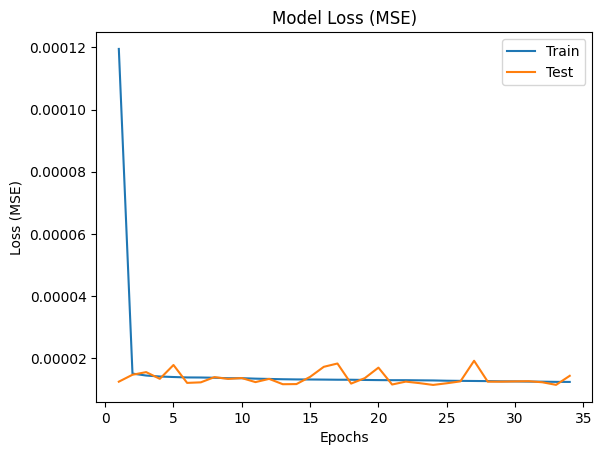

In [ ]:
# Define the range of epochs based on the length of the training history
epochs = range(1, len(history.history['mae']) + 1)

# Create a new figure for plotting training and validation loss
plt.figure()

# Plot training loss (MSE) over epochs
plt.plot(epochs, history.history['loss'], label='Train')

# Plot validation loss (MSE) over epochs
plt.plot(epochs, history.history['val_loss'], label='Test')

# Set plot title and labels for clarity
plt.title('Model Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')

# Display legend to differentiate training and validation curves
plt.legend()

# Display the plot
plt.show()

### Step 10: Evaluating the Model
In this step, we evaluate the performance of the trained neural network model on the test dataset. We use the `evaluate` method to compute the loss and mean absolute error (MAE) on the test set (`X_test` and `y_test`). The evaluation results are stored in the variables `loss` and `mae`, with `verbose=0` to suppress output during the evaluation.

To gain additional insight, we calculate the root mean square error (RMSE) by taking the square root of the loss (MSE). Finally, we print the test metrics, which include MSE, MAE, and RMSE, to comprehensively assess the model’s performance on unseen data.

In [ ]:
# Evaluate the model on the test dataset to get loss (MSE) and mean absolute error (MAE)
loss, mae = model.evaluate(X_test, y_test, verbose=0)

# Calculate the root mean square error (RMSE) for additional evaluation
rmse = np.sqrt(loss)

# Print the evaluation metrics to assess model performance on test data
print(f"Test loss (MSE): {loss}")
print(f"Test mean absolute error (MAE): {mae}")
print(f"Test root mean square error (RMSE): {rmse}")

Test loss (MSE): 1.1374268069630489e-05
Test mean absolute error (MAE): 0.002050678711384535
Test root mean square error (RMSE): 0.0033725758804851952


### Step 11: Making Predictions and Calculating Error Metrics
In this step, we use the trained neural network model to make predictions on the test dataset.

1. **Predictions:** We predict the target values for `X_test` using the `predict` method. The predicted values are stored in `y_pred`.
2. **Mean Absolute Error (MAE):** We calculate the **mean absolute error** (MAE) between the actual values (`y_test`) and the predicted values (`y_pred`), providing an indication of the average magnitude of prediction errors.
3. **Mean Absolute Percentage Error (MAPE):** We compute the **mean absolute percentage error** (MAPE) to understand the error as a percentage of the actual values, making it easier to interpret model accuracy in practical terms.
Finally, we print the first five actual and predicted values, along with the calculated MAE and MAPE, to evaluate the model's prediction accuracy.

In [ ]:
# Generate predictions using the trained model on the test dataset
y_pred = model.predict(X_test)

# Calculate the mean absolute error (MAE) between the actual and predicted values
mae = mean_absolute_error(y_test, y_pred)

# Calculate the mean absolute percentage error (MAPE) for further evaluation
mape = mean_absolute_percentage_error(y_test, y_pred)

# Display the first five actual and predicted values for comparison
print(f"Expected: {y_test[:5]}")
print(f"Predicted: {y_pred[:5].flatten()}")
print(f"Mean absolute error: {mae}")
print(f"Mean absolute percentage error (MAPE): {mape * 100:.2f}%")

12808/12808 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step
Expected: [0.12909651 0.02697809 0.0492486  0.01846822 0.11732754]
Predicted: [0.13247186 0.02782189 0.05172308 0.01835192 0.11762492]
Mean absolute error: 0.0020506764494709604
Mean absolute percentage error (MAPE): 9631511962.24%


### Step 12: Visualizing Predicted vs Actual Values
In this step, we create a scatter plot to visualize the relationship between the actual values and the predicted values from the neural network model.

1. **Scatter Plot:** We use `plt.scatter` to create a scatter plot where the x-axis represents the actual values (`y_test`) and the y-axis represents the predicted values (`y_pred`). The points are colored blue with a transparency of 0.5 to enhance visibility.
2. **Reference Line:** We add a red line representing perfect predictions (where predicted values equal actual values) using `plt.plot`. This line helps to assess how closely the predicted values align with the actual values.
3. **Title and Labels:** We set a title for the plot and label the x and y axes to clarify what each axis represents.

Finally, we display the plot using `plt.show()`, allowing us to evaluate the model's prediction performance visually.

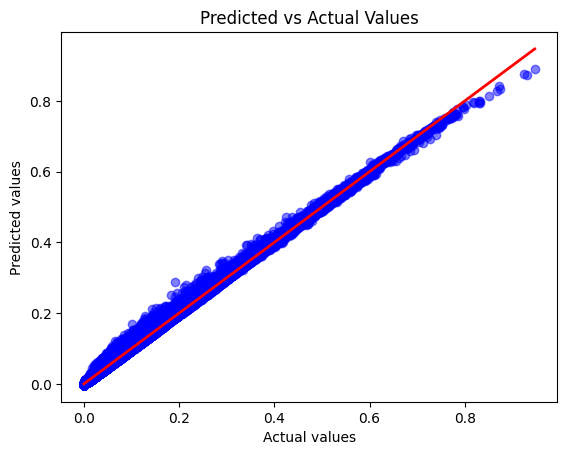

In [ ]:
# Create a figure for the scatter plot
plt.figure()

# Scatter plot of actual values versus predicted values
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)

# Plot a reference line for perfect predictions (y = x)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)

# Set the title and labels for the axes
plt.title('Predicted vs Actual Values')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')

# Display the plot
plt.show()